# Time-series trend on the 10 Binance USD-M perps. Does it move.

Ten symbols on disk, ADA, AVAX, BNB, BTC, DOGE, ETH, LINK, LTC, SOL, XRP, 2022 to 2024. Signal is the sign of trailing return over L weeks, weekly rebalance. PnL is charged the table's round-trip on a sign flip and realized funding for every 8-hour print the position is held. A long pays a positive funding rate, a short collects it. Reference lines are long-only unlevered and long-only vol-scaled.


In [1]:
import sys, os
sys.path.insert(0, os.path.dirname(os.path.abspath('.')) if not os.path.exists('loader.py') else '.')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from loader import (load_daily_panel, weekly_close, cost_round_trip_bps,
                    load_funding_panel, weekly_funding_sum)

daily = load_daily_panel()
weekly = weekly_close(daily)
fwd = weekly.pct_change().shift(-1)
costs = cost_round_trip_bps()

funding = load_funding_panel()
fwd_funding = weekly_funding_sum(funding).reindex(weekly.index).shift(-1)

print(f'daily panel {daily.shape}  range {daily.index.min().date()} .. {daily.index.max().date()}')
print(f'weekly panel {weekly.shape}')
print(f'funding panel {funding.shape}  prints, one row per 8 hours')
print('round-trip bps by symbol')
print(costs.round(2).to_string())


daily panel (1096, 10)  range 2022-01-01 .. 2024-12-31
weekly panel (158, 10)
funding panel (3363, 10)  prints, one row per 8 hours
round-trip bps by symbol
symbol
ADAUSDT     16.74
AVAXUSDT    14.72
BNBUSDT     14.41
BTCUSDT     14.03
DOGEUSDT    15.33
ETHUSDT     14.05
LINKUSDT    15.08
LTCUSDT     15.39
SOLUSDT     14.40
XRPUSDT     15.79


## Reference lines

Long-only unlevered is the equal-weight book. Long-only vol-scaled targets 1% weekly vol per symbol with a 3x cap on an 8-week realized vol. Both are the beta a trend book has to beat on the regime map, not on the pooled Sharpe.


In [2]:
def per_year(book):
    df = pd.DataFrame({'pnl': book.values}, index=book.index)
    return df.groupby(df.index.year).agg(
        n=('pnl','size'),
        mean_bps=('pnl', lambda s: s.mean()*1e4),
        sharpe=('pnl', lambda s: s.mean()/s.std()*np.sqrt(52) if s.std()>0 else np.nan),
    ).round(2)

def book_sharpe(book):
    return book.mean()/book.std()*np.sqrt(52)

lo = fwd.mean(axis=1).dropna()

vol = weekly.pct_change().rolling(8).std()
scale = (0.01 / vol).clip(upper=3.0).shift(1)
lo_vs = (fwd * scale).mean(axis=1).dropna()

print(f'long-only unlevered      Sharpe {book_sharpe(lo):.2f}   mean_bps {lo.mean()*1e4:.2f}')
print(f'long-only vol-scaled 1%  Sharpe {book_sharpe(lo_vs):.2f}   mean_bps {lo_vs.mean()*1e4:.2f}')
print()
print('long-only unlevered by year')
print(per_year(lo))
print('long-only vol-scaled by year')
print(per_year(lo_vs))


long-only unlevered      Sharpe 0.54   mean_bps 69.95
long-only vol-scaled 1%  Sharpe 0.87   mean_bps 13.32

long-only unlevered by year
       n  mean_bps  sharpe
2022  52   -189.74   -1.40
2023  53    188.12    1.69
2024  52    209.18    1.50
long-only vol-scaled by year
       n  mean_bps  sharpe
2022  43    -18.44   -1.22
2023  53     25.69    1.84
2024  52     26.97    1.66


## Trend at each lookback

Signal is sign of price[t] over price[t-L] for L in 1, 2, 4, 8, 12 weeks. Position is +/- 1 per symbol, weekly rebalance. Book is the equal-weight mean of per-symbol weekly PnL. Cost is charged on a sign flip. Funding is charged on every 8-hour print the position is held, sign * funding is the drag on a long paying it and the credit to a short collecting it.


In [3]:
def trend_book(L, cost_mult=1.0, include_funding=True):
    net_parts, gross_parts, flips_parts, fund_parts = [], [], [], []
    for sym in weekly.columns:
        trailing = weekly[sym] / weekly[sym].shift(L) - 1.0
        sig = np.sign(trailing)
        r = fwd[sym]
        idx = sig.dropna().index.intersection(r.dropna().index)
        sig, r = sig.loc[idx], r.loc[idx]
        f = fwd_funding[sym].reindex(idx).fillna(0.0)
        flips = (sig != sig.shift(1)).astype(float)
        gross = sig * r
        fund_pnl = -sig * f if include_funding else pd.Series(0.0, index=idx)
        net = gross + fund_pnl - flips * costs[sym] * cost_mult / 1e4
        net_parts.append(net.rename(sym))
        gross_parts.append(gross.rename(sym))
        flips_parts.append(flips.rename(sym))
        fund_parts.append(fund_pnl.rename(sym))
    return (pd.concat(net_parts, axis=1),
            pd.concat(gross_parts, axis=1),
            pd.concat(flips_parts, axis=1),
            pd.concat(fund_parts, axis=1))

LOOKBACKS = [1, 2, 4, 8, 12]
results = {L: trend_book(L) for L in LOOKBACKS}
results_nofund = {L: trend_book(L, include_funding=False) for L in LOOKBACKS}

rows = []
for L in LOOKBACKS:
    net_df, gross_df, flips_df, fund_df = results[L]
    net_nofund = results_nofund[L][0].mean(axis=1)
    net_book = net_df.mean(axis=1)
    rows.append({
        'L_weeks': L,
        'sharpe_nofund': book_sharpe(net_nofund),
        'sharpe_withfund': book_sharpe(net_book),
        'mean_bps_withfund': net_book.mean()*1e4,
        'funding_drag_bps': fund_df.mean(axis=1).mean()*1e4,
        'flips_per_yr': flips_df.mean().mean()*52,
    })
grid = pd.DataFrame(rows).set_index('L_weeks').round(2)
print(grid)


         sharpe_nofund  sharpe_withfund  mean_bps_withfund  funding_drag_bps  \
L_weeks                                                                        
1                 0.84             0.78              73.82             -6.15   
2                -0.09            -0.14             -13.28             -4.01   
4                 0.71             0.61              58.70            -10.07   
8                -0.14            -0.24             -21.91             -8.61   
12                0.15             0.06               6.37             -9.07   

         flips_per_yr  
L_weeks                
1               24.97  
2               17.98  
4               12.17  
8                9.70  
12               8.54  


## Sharpe by lookback

The book Sharpe as a function of L, net of table cost. The two horizontal lines are the long-only beta baselines. A sign that lives on trend should show a coherent shape across L, not a sawtooth.


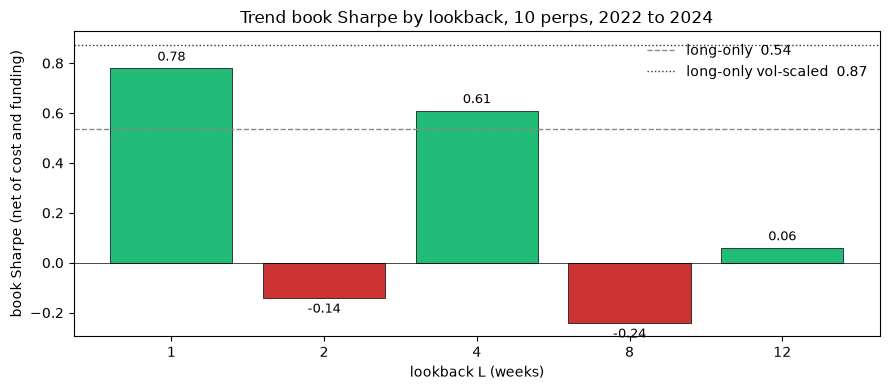

In [4]:
fig, ax = plt.subplots(figsize=(9, 4))
colors = ['#2b7' if s>0 else '#c33' for s in grid['sharpe_withfund']]
ax.bar(grid.index.astype(str), grid['sharpe_withfund'], color=colors, edgecolor='k', linewidth=0.5)
ax.axhline(book_sharpe(lo), color='#888', ls='--', lw=1, label=f'long-only  {book_sharpe(lo):.2f}')
ax.axhline(book_sharpe(lo_vs), color='#333', ls=':', lw=1, label=f'long-only vol-scaled  {book_sharpe(lo_vs):.2f}')
ax.axhline(0, color='k', lw=0.5)
for L, s in grid['sharpe_withfund'].items():
    ax.text(str(L), s + (0.03 if s>=0 else -0.06), f'{s:.2f}', ha='center', fontsize=9)
ax.set_xlabel('lookback L (weeks)')
ax.set_ylabel('book Sharpe (net of cost and funding)')
ax.set_title('Trend book Sharpe by lookback, 10 perps, 2022 to 2024')
ax.legend(loc='upper right', frameon=False)
plt.tight_layout()
plt.show()


L=1 and L=4 are the two positive cells. L=2 and L=8 are negative, L=12 is small. L=1 clears the long-only unlevered line but sits below the vol-scaled variant on the pooled Sharpe. L=4 sits below both. Neighbours in the grid do not agree, which is the first sign the shape is more noise than signal.


## Funding drag

How much a trend book pays or collects in funding, and how that moves the Sharpe. A long pays when funding is positive, a short collects. A trend book that spends about half the time on each side sees the two largely cancel on average.


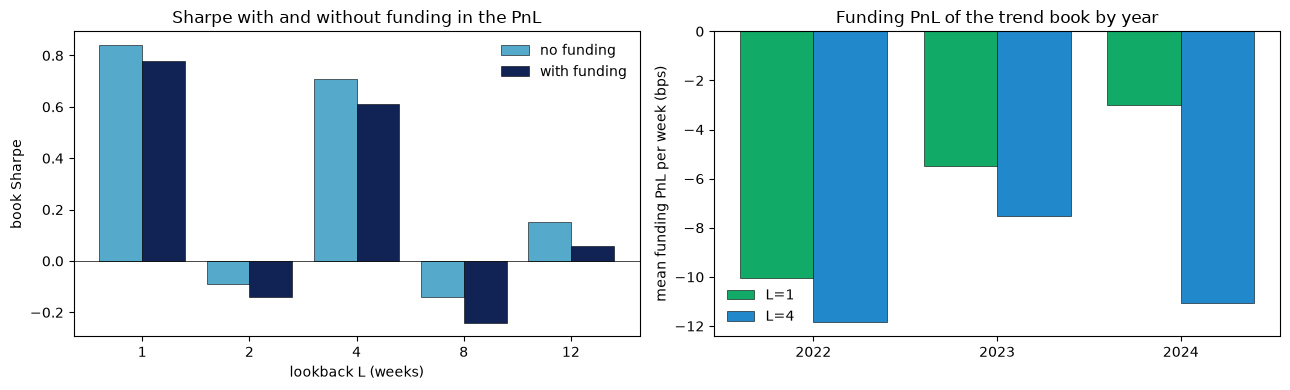

In [5]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

x = np.arange(len(LOOKBACKS))
w = 0.4
ax1.bar(x - w/2, grid['sharpe_nofund'], width=w, label='no funding', color='#5ac', edgecolor='k', linewidth=0.4)
ax1.bar(x + w/2, grid['sharpe_withfund'], width=w, label='with funding', color='#125', edgecolor='k', linewidth=0.4)
ax1.axhline(0, color='k', lw=0.5)
ax1.set_xticks(x); ax1.set_xticklabels([str(L) for L in LOOKBACKS])
ax1.set_xlabel('lookback L (weeks)')
ax1.set_ylabel('book Sharpe')
ax1.set_title('Sharpe with and without funding in the PnL')
ax1.legend(frameon=False)

years = sorted(set(results[1][0].index.year))
fund_l1_yr = results[1][3].mean(axis=1).groupby(results[1][3].index.year).mean() * 1e4
fund_l4_yr = results[4][3].mean(axis=1).groupby(results[4][3].index.year).mean() * 1e4
xy = np.arange(len(years))
ax2.bar(xy - w/2, fund_l1_yr.reindex(years).values, width=w, label='L=1', color='#1a6', edgecolor='k', linewidth=0.4)
ax2.bar(xy + w/2, fund_l4_yr.reindex(years).values, width=w, label='L=4', color='#28c', edgecolor='k', linewidth=0.4)
ax2.axhline(0, color='k', lw=0.5)
ax2.set_xticks(xy); ax2.set_xticklabels([str(y) for y in years])
ax2.set_ylabel('mean funding PnL per week (bps)')
ax2.set_title('Funding PnL of the trend book by year')
ax2.legend(frameon=False)
plt.tight_layout()
plt.show()


L=1 loses about 0.06 Sharpe to funding and L=4 loses about 0.10. L=4 pays more because it holds a position longer, so a stretch of positive funding accumulates before the sign turns. On the mean the book is charged only a few bps a week, small because the sign spends time on both sides. On the tails 2022 was funding-favorable to shorts and 2024 was funding-costly to longs.


## Equity over time

Where trend earns its place. The long-only book loses through 2022 and recovers in 2023 and 2024. The vol-scaled variant softens the loss but does not flip its sign. Trend L=1 and L=4 are up through 2022 because a bear turns the sign short. This is a different regime map, not a better beta.


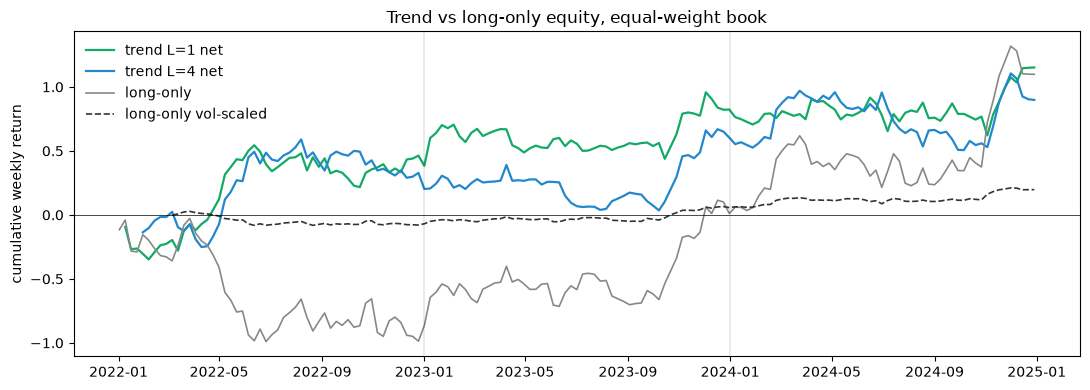

In [6]:
def cum(book):
    return book.fillna(0).cumsum()

net_l1 = results[1][0].mean(axis=1)
net_l4 = results[4][0].mean(axis=1)

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(cum(net_l1).index, cum(net_l1).values, label='trend L=1 net', color='#1a6', lw=1.6)
ax.plot(cum(net_l4).index, cum(net_l4).values, label='trend L=4 net', color='#28c', lw=1.6)
ax.plot(cum(lo).index, cum(lo).values, label='long-only', color='#888', lw=1.2)
ax.plot(cum(lo_vs).index, cum(lo_vs).values, label='long-only vol-scaled', color='#333', lw=1.2, ls='--')
for y in [2023, 2024]:
    ax.axvline(pd.Timestamp(f'{y}-01-01', tz='UTC'), color='k', lw=0.3, alpha=0.4)
ax.axhline(0, color='k', lw=0.5)
ax.set_ylabel('cumulative weekly return')
ax.set_title('Trend vs long-only equity, equal-weight book')
ax.legend(loc='upper left', frameon=False)
plt.tight_layout()
plt.show()


## Sharpe by year

Grouped Sharpe by calendar year. The trend books are close to flat across the three years. The long-only books swing from a heavy negative in 2022 to a heavy positive in 2023 and 2024.


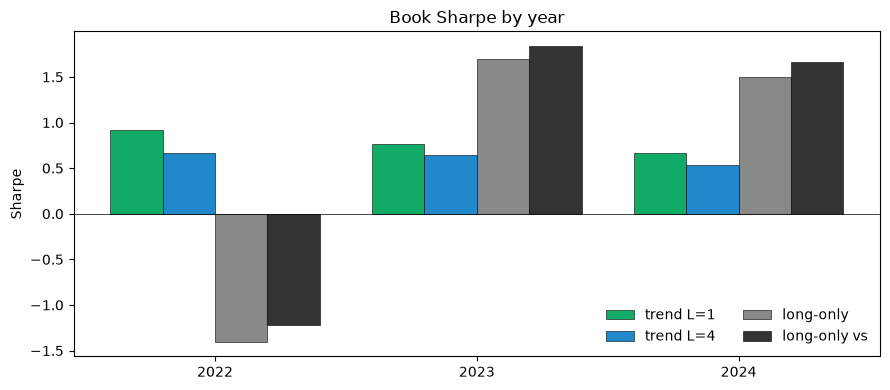

In [7]:
def sharpe_by_year(book):
    df = pd.DataFrame({'pnl': book.values}, index=book.index)
    return df.groupby(df.index.year)['pnl'].apply(
        lambda s: s.mean()/s.std()*np.sqrt(52) if s.std()>0 else np.nan)

years = sorted(set(net_l1.index.year))
series = {'trend L=1': sharpe_by_year(net_l1),
          'trend L=4': sharpe_by_year(net_l4),
          'long-only': sharpe_by_year(lo),
          'long-only vs': sharpe_by_year(lo_vs)}
df = pd.DataFrame(series).reindex(years)

fig, ax = plt.subplots(figsize=(9, 4))
w = 0.2
x = np.arange(len(years))
colors = {'trend L=1':'#1a6','trend L=4':'#28c','long-only':'#888','long-only vs':'#333'}
for i, col in enumerate(df.columns):
    ax.bar(x + (i-1.5)*w, df[col].values, width=w, label=col, color=colors[col], edgecolor='k', linewidth=0.4)
ax.set_xticks(x)
ax.set_xticklabels([str(y) for y in years])
ax.axhline(0, color='k', lw=0.5)
ax.set_ylabel('Sharpe')
ax.set_title('Book Sharpe by year')
ax.legend(loc='lower right', frameon=False, ncol=2)
plt.tight_layout()
plt.show()


## Per-symbol lean

Per-symbol Sharpe at L=1 and L=4 and the flip rate that drives cost. A book Sharpe that leans on two or three names is fragile because one of them fading kills the book.


          sharpe_L1  flips_yr_L1  sharpe_L4  flips_yr_L4
AVAXUSDT       1.17        23.00       0.84         9.18
DOGEUSDT       1.12        24.67       0.24        13.25
ETHUSDT        1.05        24.67       0.40        12.58
XRPUSDT        0.65        24.33       0.50        14.61
LTCUSDT        0.26        24.33       0.02        13.25
ADAUSDT        0.26        23.00      -0.04        10.54
BNBUSDT        0.15        26.67       0.21        14.27
BTCUSDT        0.01        27.67       0.95        11.22
SOLUSDT       -0.03        25.33       0.63        10.54
LINKUSDT      -0.45        26.00      -0.09        12.24


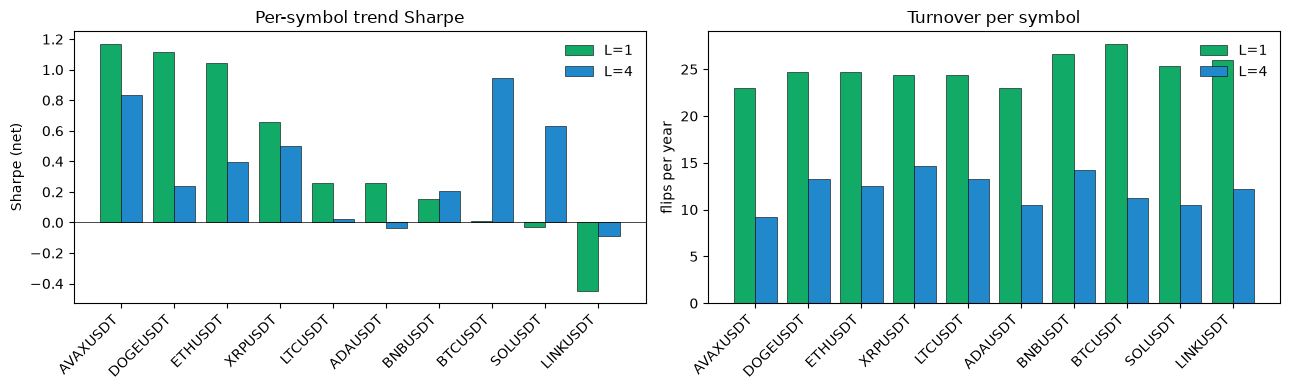

In [8]:
def per_sym_stats(L):
    net_df, _, flips_df, _ = results[L]
    out = pd.DataFrame({
        f'sharpe_L{L}': net_df.apply(lambda s: s.mean()/s.std()*np.sqrt(52) if s.std()>0 else np.nan),
        f'flips_yr_L{L}': flips_df.mean()*52,
    })
    return out

ps = pd.concat([per_sym_stats(1), per_sym_stats(4)], axis=1)
ps = ps.sort_values('sharpe_L1', ascending=False)
print(ps.round(2))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
x = np.arange(len(ps.index))
w = 0.4
ax1.bar(x - w/2, ps['sharpe_L1'], width=w, label='L=1', color='#1a6', edgecolor='k', linewidth=0.4)
ax1.bar(x + w/2, ps['sharpe_L4'], width=w, label='L=4', color='#28c', edgecolor='k', linewidth=0.4)
ax1.axhline(0, color='k', lw=0.5)
ax1.set_xticks(x); ax1.set_xticklabels(ps.index, rotation=45, ha='right')
ax1.set_ylabel('Sharpe (net)')
ax1.set_title('Per-symbol trend Sharpe')
ax1.legend(frameon=False)
ax2.bar(x - w/2, ps['flips_yr_L1'], width=w, label='L=1', color='#1a6', edgecolor='k', linewidth=0.4)
ax2.bar(x + w/2, ps['flips_yr_L4'], width=w, label='L=4', color='#28c', edgecolor='k', linewidth=0.4)
ax2.set_xticks(x); ax2.set_xticklabels(ps.index, rotation=45, ha='right')
ax2.set_ylabel('flips per year')
ax2.set_title('Turnover per symbol')
ax2.legend(frameon=False)
plt.tight_layout()
plt.show()


## Cost sensitivity

Book net Sharpe at 0x, 1x, 2x the table cost. A sign that flips between 1x and 2x is not robust. A survivor stays the same sign at 2x.


cost_x   0.0   1.0   2.0
L                       
1       0.86  0.78  0.71
2      -0.08 -0.14 -0.19
4       0.65  0.61  0.57
8      -0.21 -0.24 -0.27
12      0.09  0.06  0.04


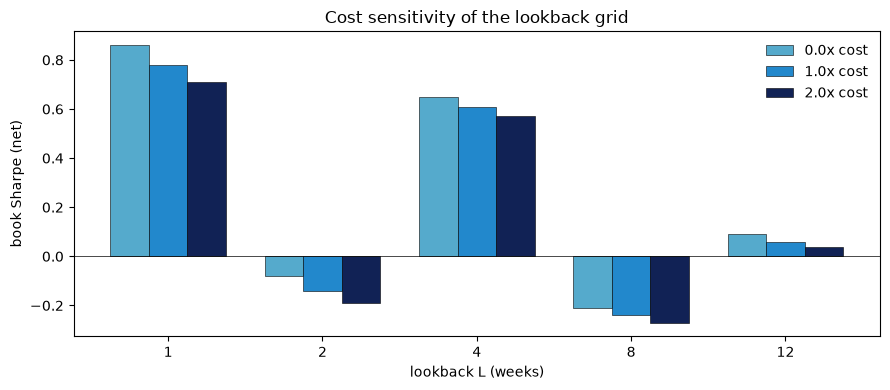

In [9]:
cost_mults = [0.0, 1.0, 2.0]
rows = []
for L in LOOKBACKS:
    for m in cost_mults:
        net_df, _, _, _ = trend_book(L, cost_mult=m)
        book = net_df.mean(axis=1)
        rows.append({'L': L, 'cost_x': m, 'sharpe': book_sharpe(book)})
cs = pd.DataFrame(rows).pivot(index='L', columns='cost_x', values='sharpe').round(2)
print(cs)

fig, ax = plt.subplots(figsize=(9, 4))
w = 0.25
x = np.arange(len(LOOKBACKS))
for i, m in enumerate(cost_mults):
    ax.bar(x + (i-1)*w, cs[m].values, width=w, label=f'{m}x cost',
           color=['#5ac','#28c','#125'][i], edgecolor='k', linewidth=0.4)
ax.axhline(0, color='k', lw=0.5)
ax.set_xticks(x); ax.set_xticklabels([str(L) for L in LOOKBACKS])
ax.set_xlabel('lookback L (weeks)')
ax.set_ylabel('book Sharpe (net)')
ax.set_title('Cost sensitivity of the lookback grid')
ax.legend(frameon=False)
plt.tight_layout()
plt.show()


## Finding

Trend moves at L=1 and L=4 on these 10 perps. Book Sharpe 0.78 and 0.61 net of round-trip cost and realized funding, positive in every calendar year, and unchanged in sign at 2x cost. Cost drag is small (about 0.08 Sharpe) and funding drag is small too (0.06 at L=1, 0.10 at L=4). Neither one is what would kill the signal.

The case is not the pooled headline. Long-only vol-scaled beats trend L=1 on pooled Sharpe (0.87 vs 0.78). What trend adds is a different regime map. The beta books lose about 1.2 to 1.4 Sharpe in 2022, trend L=1 earns +0.91 there and L=4 earns +0.66. A book that owns both harvests both regimes.

## Softness

The lookback grid is a sawtooth. L=1 wins, L=2 is negative, L=4 wins again, L=8 is negative, L=12 is small. Winner minus median Sharpe is 0.9. Only three years, 156 weekly observations per symbol. BTC L=1 Sharpe is close to zero so the L=1 book leans on AVAX, DOGE, ETH.